In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pa_gs = pd.read_csv('data/pa_data.csv')


pa_gs = pa_gs[pa_gs['year'] >= 1960]

coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]
east_pa_stations = pa_gs[pa_gs['longitude'] < -77.569]
west_pa_stations = pa_gs[pa_gs['longitude'] > -77.569]
north_pa_stations = pa_gs[pa_gs['latitude'] > 40.58]
south_pa_stations = pa_gs[pa_gs['latitude'] < 40.58]
high_elevation_pa_stations = pa_gs[pa_gs['elevation_m'] > 371.9]
low_elevation_pa_stations = pa_gs[pa_gs['elevation_m']< 139.9]

subsets = {'Coastal PA': coastal_pa_stations, 'Lakeside PA': lakeside_pa_stations, 'Inland PA': inland_pa_stations,
           'Eastern PA': east_pa_stations, 'Western PA': west_pa_stations, 'Northern PA': north_pa_stations, 'Southern PA': south_pa_stations,
           'Low Elevation PA': low_elevation_pa_stations, 'High Elevation PA': high_elevation_pa_stations}

def remove_nulls_simple(data_subset, variables):
        # Drop rows where any of the specified variable columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=variables, ignore_index=True)
        # Subsets the cleaned dataframe back into only chosen variables
        vars_cleaned = data_subset_cleaned[variables]
        return vars_cleaned

# find the 1st and 3rd quartiles of each year of data for GSL and DTR
# subtract the 1st quartile value from the 3rd quartile value for the IQR
# plot yearly IQRs against time
# determine whether there's a statistically significant change in the IQR values

In [3]:
def plot_IQR_trend(data, data_name, var1, var2):
    data_cleaned = remove_nulls_simple(data, ['year', 'station_name', var1, var2])
    data_cleaned = data_cleaned.groupby('year').agg({var1: ['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)],
                                              var2: ['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]})
    data_cleaned.columns = ['var1_mean', 'var1_q1', 'var1_q3', 'var2_mean', 'var2_q1', 'var2_q3']
    data_cleaned = data_cleaned.reset_index()
    var1_IQR = data_cleaned['var1_q3'] - data_cleaned['var1_q1']
    var2_IQR = data_cleaned['var2_q3'] - data_cleaned['var2_q1']
    var1_IQR = var1_IQR.to_frame()
    var2_IQR = var2_IQR.to_frame()
    data_cleaned = pd.concat([data_cleaned, var1_IQR, var2_IQR], axis=1)
    data_cleaned.columns = ['year', f'{var1}_mean', f'{var1}_q1', f'{var1}_q3', f'{var2}_mean', f'{var2}_q1', f'{var2}_q3', f'{var1}_IQR', f'{var2}_IQR']

    fig, axs = plt.subplots(3,2, sharex=True, figsize = (10,8))
    fig.suptitle('IQR trends')
    axs[0,0] = sns.lineplot(data = data_cleaned, x ='year', y = f'{var1}_IQR', ax = axs[0,0])
    axs[0,0].set_title(f'{data_name} {var1}')
    axs[0,1] = sns.lineplot(data = data_cleaned, x ='year', y = f'{var2}_IQR', ax = axs[0,1])
    axs[0,1].set_title(f'{data_name} {var2}')
    axs[1,0] = sns.regplot(data = data_cleaned, x ='year', y = f'{var1}_IQR', order = 1, ax = axs[1,0])
    axs[1,0].set_title(f'{data_name} {var1}')
    axs[1,1] = sns.regplot(data = data_cleaned, x ='year', y = f'{var2}_IQR', order = 1, ax = axs[1,1])
    axs[1,1].set_title(f'{data_name} {var2}')
    axs[2,0] = sns.regplot(data = data_cleaned, x ='year', y = f'{var1}_IQR', order = 2, ax = axs[2,0])
    axs[2,0].set_title(f'{data_name} {var1}')
    axs[2,1] = sns.regplot(data = data_cleaned, x ='year', y = f'{var2}_IQR', order = 2, ax = axs[2,1])
    axs[2,1].set_title(f'{data_name} {var2}')
    plt.show()

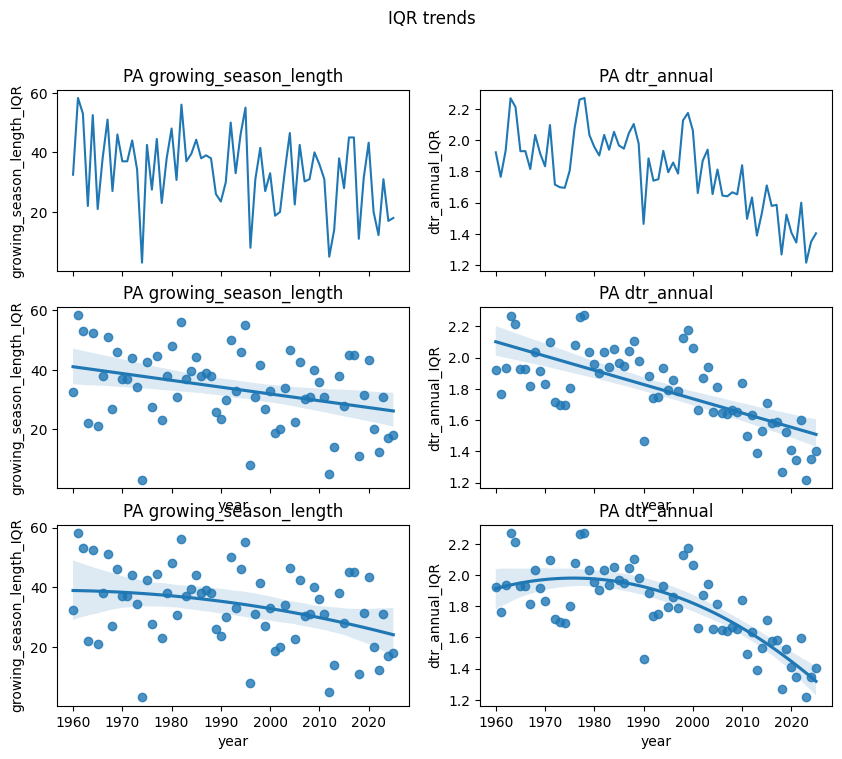

In [4]:
plot_IQR_trend(pa_gs, 'PA', 'growing_season_length', 'dtr_annual')

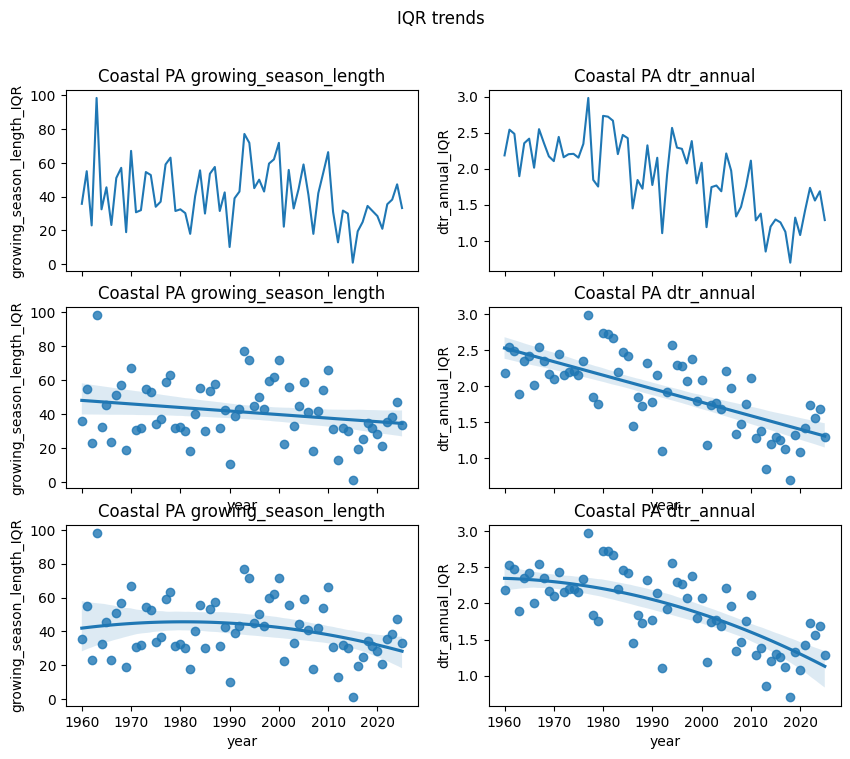

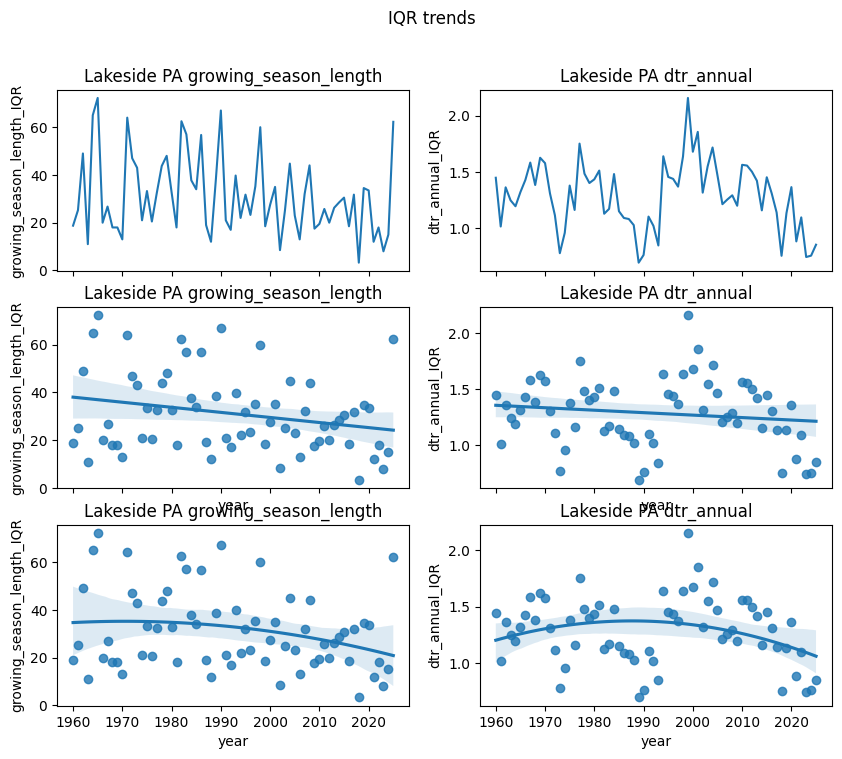

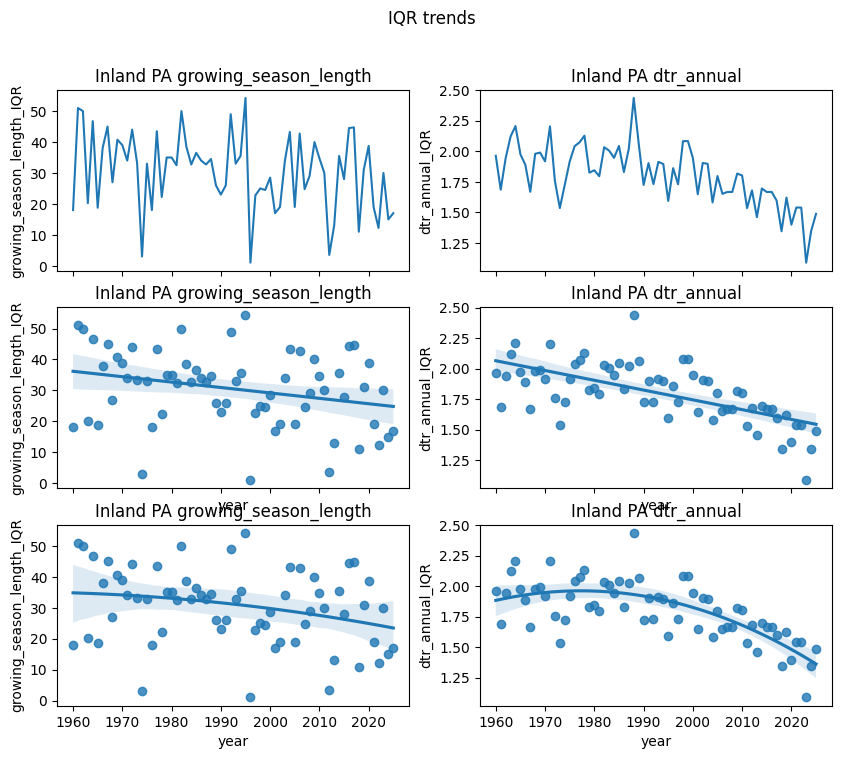

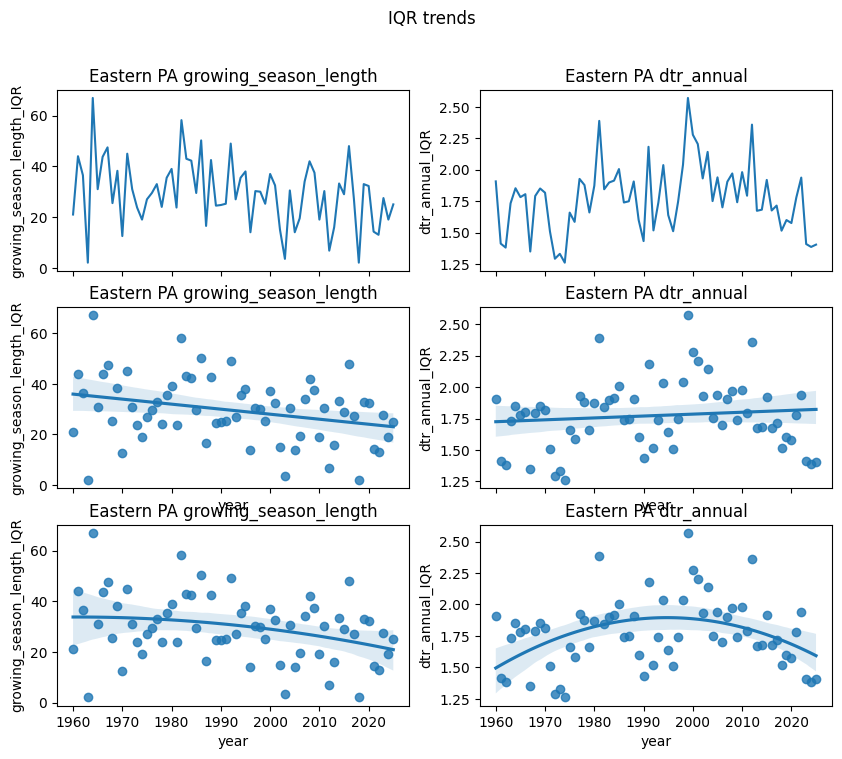

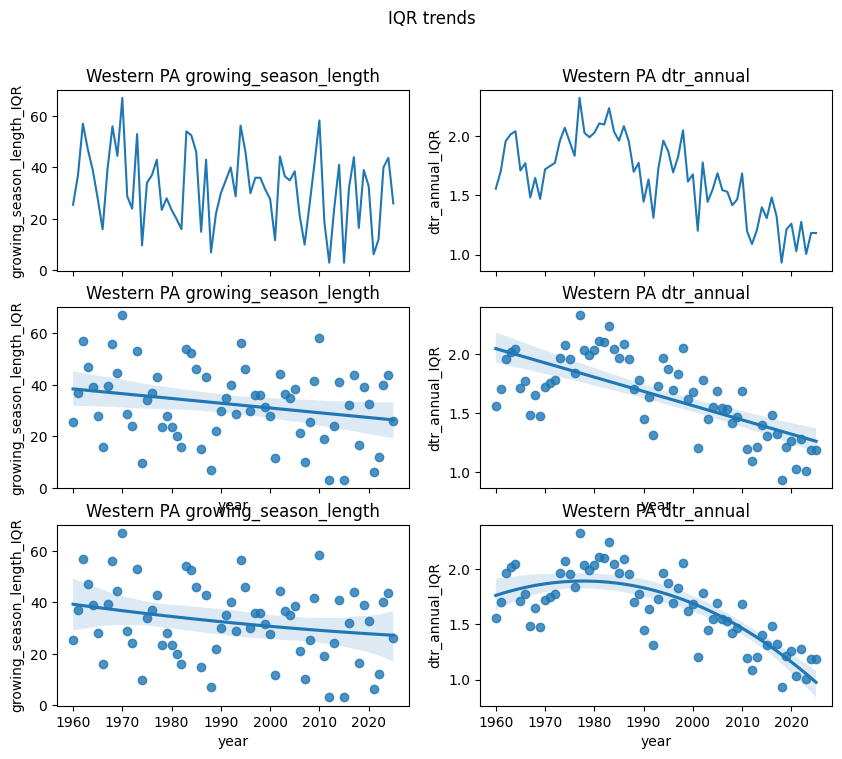

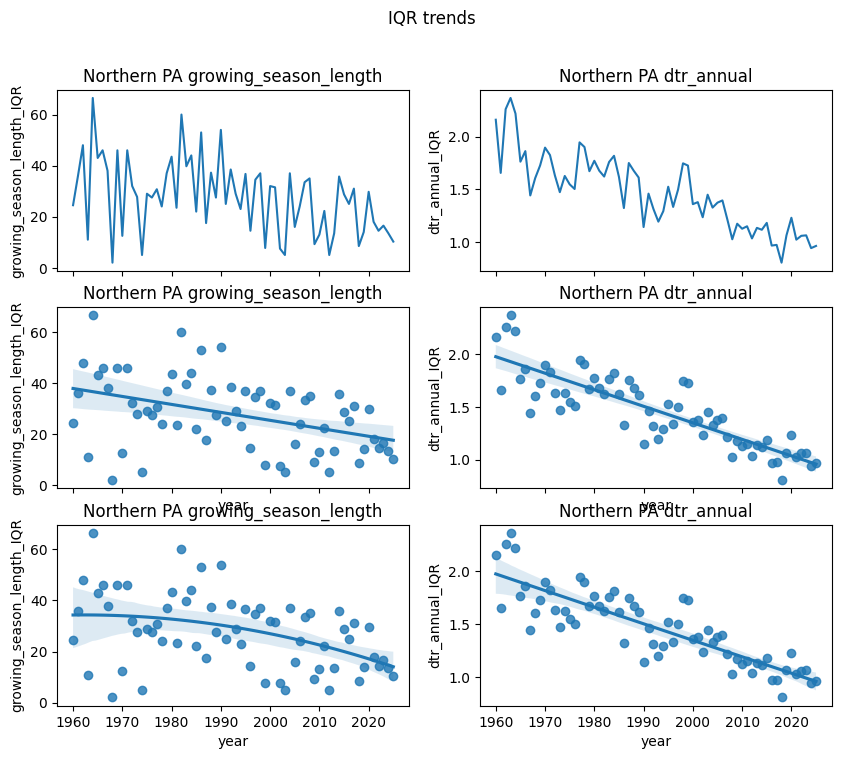

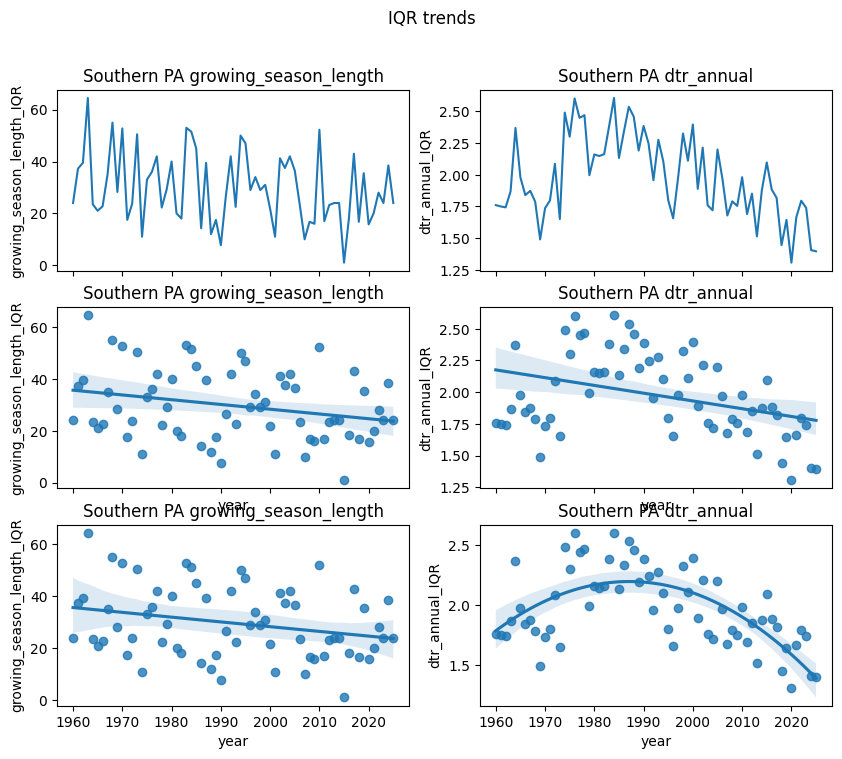

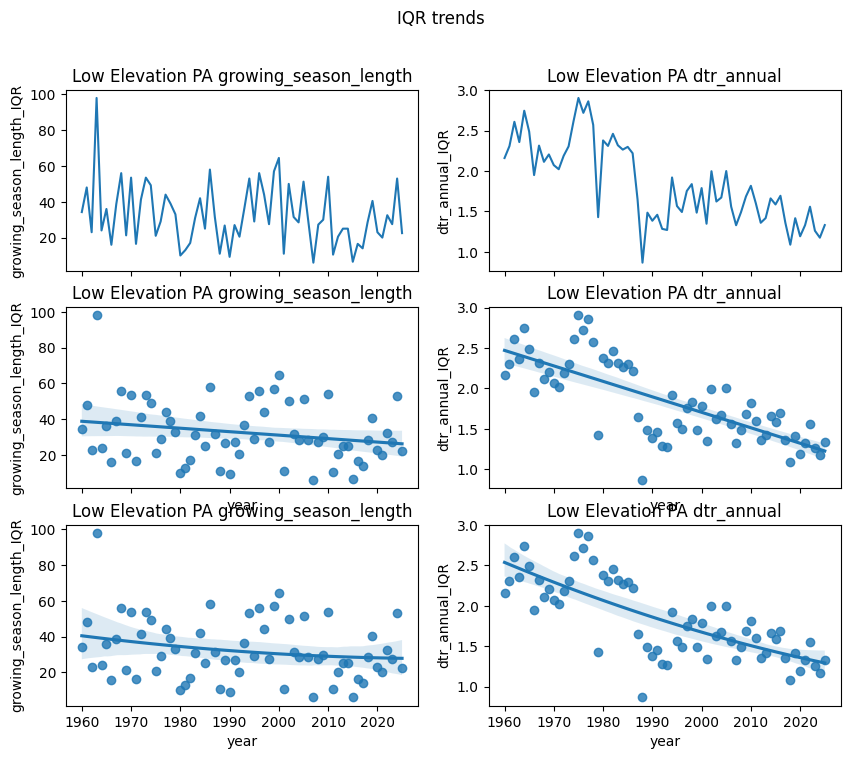

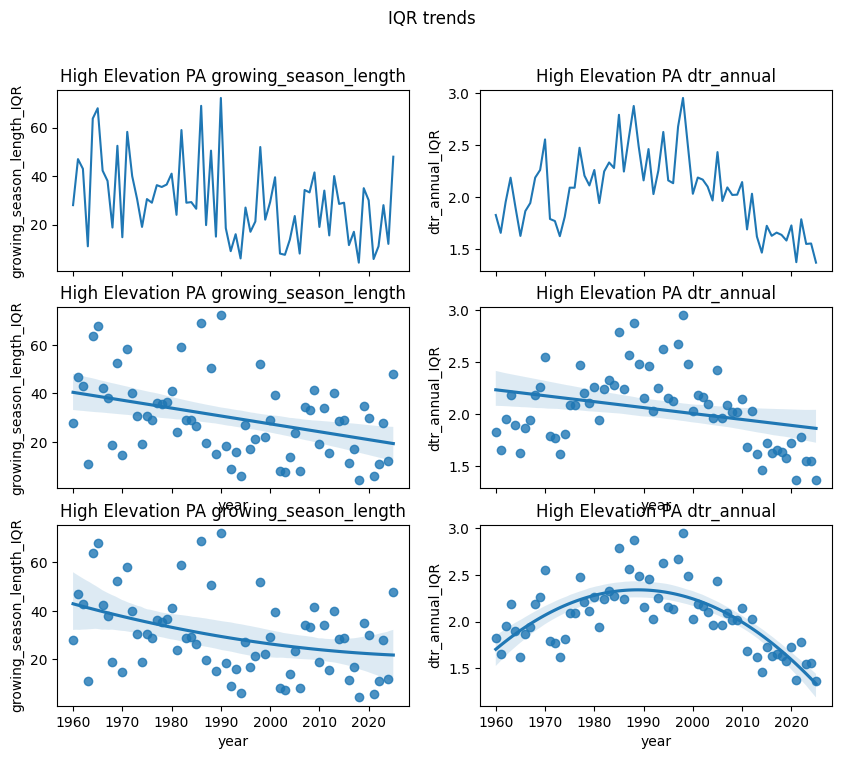

In [5]:
for subset_name, subset_data in subsets.items():
    plot_IQR_trend(subset_data, subset_name, 'growing_season_length', 'dtr_annual')

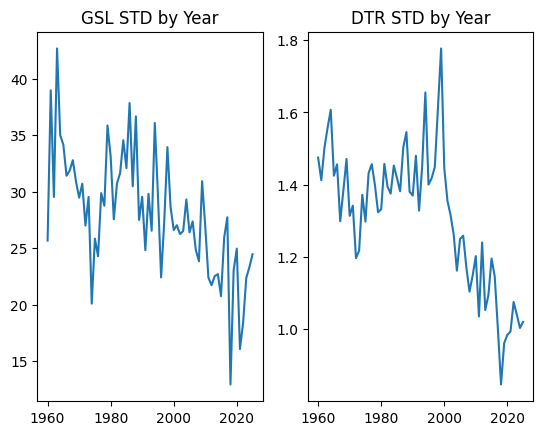

In [22]:
pa_gsl_std_by_yr = pa_gs.groupby('year')['growing_season_length'].std()
pa_dtr_std_by_yr = pa_gs.groupby('year')['dtr_annual'].std()
fig, axs = plt.subplots(1,2)
axs[0].plot(pa_gsl_std_by_yr)
axs[0].set_title('GSL STD by Year')
axs[1].plot(pa_dtr_std_by_yr)
axs[1].set_title('DTR STD by Year')
plt.show()